# Improved Speech Emotion Recognition
## Key Improvements:
- Enhanced feature extraction (MFCCs, chroma, mel, contrast, tonnetz)
- CNN-LSTM hybrid architecture
- Data augmentation
- Label consolidation
- Better regularization and callbacks

In [1]:
# Install required packages
!pip install librosa 
!pip install numpy 
!pip install pandas 
!pip install scikit-learn
!pip install
!pip install tensorflow
!pip install matplotlib 
!pip install seaborn

ERROR: You must give at least one requirement to install (see "pip help install")


In [2]:
import pandas as pd
import numpy as np
import os
import librosa
import librosa.display
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Conv1D, MaxPooling1D, Flatten, Dropout, BatchNormalization, LSTM, Bidirectional
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)
import tensorflow as tf
tf.random.set_seed(42)

## 1. Enhanced Feature Extraction

In [3]:
def extract_features(file_path, duration=3, sr=22050):
    """
    Extract comprehensive audio features:
    - MFCCs (40 coefficients)
    - Chroma features
    - Mel spectrogram
    - Spectral contrast
    - Tonnetz (tonal centroid features)
    """
    try:
        # Load audio file
        audio, sample_rate = librosa.load(file_path, duration=duration, sr=sr)
        
        # Extract MFCCs (40 coefficients for better feature representation)
        mfccs = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=40)
        mfccs_mean = np.mean(mfccs.T, axis=0)
        mfccs_std = np.std(mfccs.T, axis=0)
        
        # Extract Chroma features
        chroma = librosa.feature.chroma_stft(y=audio, sr=sample_rate)
        chroma_mean = np.mean(chroma.T, axis=0)
        chroma_std = np.std(chroma.T, axis=0)
        
        # Extract Mel Spectrogram
        mel = librosa.feature.melspectrogram(y=audio, sr=sample_rate)
        mel_mean = np.mean(mel.T, axis=0)
        mel_std = np.std(mel.T, axis=0)
        
        # Extract Spectral Contrast
        contrast = librosa.feature.spectral_contrast(y=audio, sr=sample_rate)
        contrast_mean = np.mean(contrast.T, axis=0)
        contrast_std = np.std(contrast.T, axis=0)
        
        # Extract Tonnetz (Tonal Centroid Features)
        tonnetz = librosa.feature.tonnetz(y=audio, sr=sample_rate)
        tonnetz_mean = np.mean(tonnetz.T, axis=0)
        tonnetz_std = np.std(tonnetz.T, axis=0)
        
        # Concatenate all features
        features = np.concatenate([
            mfccs_mean, mfccs_std,
            chroma_mean, chroma_std,
            mel_mean, mel_std,
            contrast_mean, contrast_std,
            tonnetz_mean, tonnetz_std
        ])
        
        return features
    
    except Exception as e:
        print(f"Error processing {file_path}: {e}")
        return None

In [4]:
def augment_audio(audio, sr):
    """
    Apply data augmentation techniques:
    - Time stretching
    - Pitch shifting
    - Adding noise
    """
    augmented = []
    
    # Original
    augmented.append(audio)
    
    # Time stretch (faster)
    audio_fast = librosa.effects.time_stretch(audio, rate=1.1)
    augmented.append(audio_fast)
    
    # Time stretch (slower)
    audio_slow = librosa.effects.time_stretch(audio, rate=0.9)
    augmented.append(audio_slow)
    
    # Pitch shift (up)
    audio_pitch_up = librosa.effects.pitch_shift(audio, sr=sr, n_steps=2)
    augmented.append(audio_pitch_up)
    
    # Pitch shift (down)
    audio_pitch_down = librosa.effects.pitch_shift(audio, sr=sr, n_steps=-2)
    augmented.append(audio_pitch_down)
    
    # Add white noise
    noise = np.random.randn(len(audio))
    audio_noise = audio + 0.005 * noise
    augmented.append(audio_noise)
    
    return augmented

## 2. Load and Prepare Data

In [5]:
def get_emotion_from_filename(file_path, dataset_name):
    """
    Extract emotion label from filename based on dataset conventions.
    """
    filename = os.path.basename(file_path)
    
    if dataset_name == 'RAVDESS':
        # RAVDESS: 03-01-emotion-...
        emotion_code = filename.split('-')[2]
        emotion_dict = {
            '01': 'neutral', '02': 'calm', '03': 'happy', '04': 'sad',
            '05': 'angry', '06': 'fear', '07': 'disgust', '08': 'surprise'
        }
        return emotion_dict.get(emotion_code, 'unknown')
    
    elif dataset_name == 'TESS':
        # TESS: OAF_back_angry.wav
        emotion = filename.split('_')[-1].replace('.wav', '')
        # Map 'ps' to 'surprise' if needed
        if emotion == 'ps':
            return 'surprise'
        return emotion.lower()
    
    elif dataset_name == 'CREMA-D':
        # CREMA-D: 1001_DFA_ANG_XX.wav
        parts = filename.split('_')
        if len(parts) >= 3:
            emotion_code = parts[2]
            emotion_dict = {
                'ANG': 'angry', 'DIS': 'disgust', 'FEA': 'fear',
                'HAP': 'happy', 'NEU': 'neutral', 'SAD': 'sad'
            }
            return emotion_dict.get(emotion_code, 'unknown')
    
    elif dataset_name == 'SAVEE':
        # SAVEE: DC_a01.wav
        emotion_code = filename[3]
        emotion_dict = {
            'a': 'angry', 'd': 'disgust', 'f': 'fear',
            'h': 'happy', 'n': 'neutral', 'sa': 'sad', 'su': 'surprise'
        }
        return emotion_dict.get(emotion_code, 'unknown')
    
    return 'unknown'

In [6]:
import kagglehub

In [7]:
# UPDATE THESE PATHS TO YOUR DATASET LOCATIONS
dataset_paths = {
    'RAVDESS': kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio"),
    'CREMA-D': kagglehub.dataset_download("ejlok1/cremad"),
    'TESS': kagglehub.dataset_download("ejlok1/toronto-emotional-speech-set-tess"),
    'SAVEE': kagglehub.dataset_download("ejlok1/surrey-audiovisual-expressed-emotion-savee")  # Update this
}

# Collect all audio files and labels
data = []

for dataset_name, dataset_path in dataset_paths.items():
    if not os.path.exists(dataset_path):
        print(f"Warning: {dataset_name} path not found: {dataset_path}")
        continue
    
    print(f"Processing {dataset_name}...")
    
    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.endswith('.wav'):
                file_path = os.path.join(root, file)
                emotion = get_emotion_from_filename(file_path, dataset_name)
                
                if emotion != 'unknown':
                    data.append({
                        'path': file_path,
                        'emotion': emotion,
                        'dataset': dataset_name
                    })

# Create DataFrame
df = pd.DataFrame(data)
print(f"\nTotal audio files loaded: {len(df)}")
print(f"\nEmotion distribution:")
print(df['emotion'].value_counts())

Processing RAVDESS...
Processing CREMA-D...
Processing TESS...
Processing SAVEE...

Total audio files loaded: 16282

Emotion distribution:
emotion
happy       2515
angry       2515
fear        2515
disgust     2515
sad         2455
neutral     2199
surprise    1184
calm         384
Name: count, dtype: int64


In [8]:
df

,path,emotion,dataset
0,C:\Users\a\.cache\kagglehub\datasets\uwrfkaggl...,neutral,RAVDESS
1,C:\Users\a\.cache\kagglehub\datasets\uwrfkaggl...,neutral,RAVDESS
2,C:\Users\a\.cache\kagglehub\datasets\uwrfkaggl...,neutral,RAVDESS
3,C:\Users\a\.cache\kagglehub\datasets\uwrfkaggl...,neutral,RAVDESS
4,C:\Users\a\.cache\kagglehub\datasets\uwrfkaggl...,calm,RAVDESS
...,...,...,...
16277,C:\Users\a\.cache\kagglehub\datasets\ejlok1\su...,neutral,SAVEE
16278,C:\Users\a\.cache\kagglehub\datasets\ejlok1\su...,neutral,SAVEE
16279,C:\Users\a\.cache\kagglehub\datasets\ejlok1\su...,neutral,SAVEE
16280,C:\Users\a\.cache\kagglehub\datasets\ejlok1\su...,neutral,SAVEE



Emotion distribution after consolidation:
emotion
neutral     2583
happy       2515
angry       2515
fear        2515
disgust     2515
sad         2455
surprise    1184
Name: count, dtype: int64


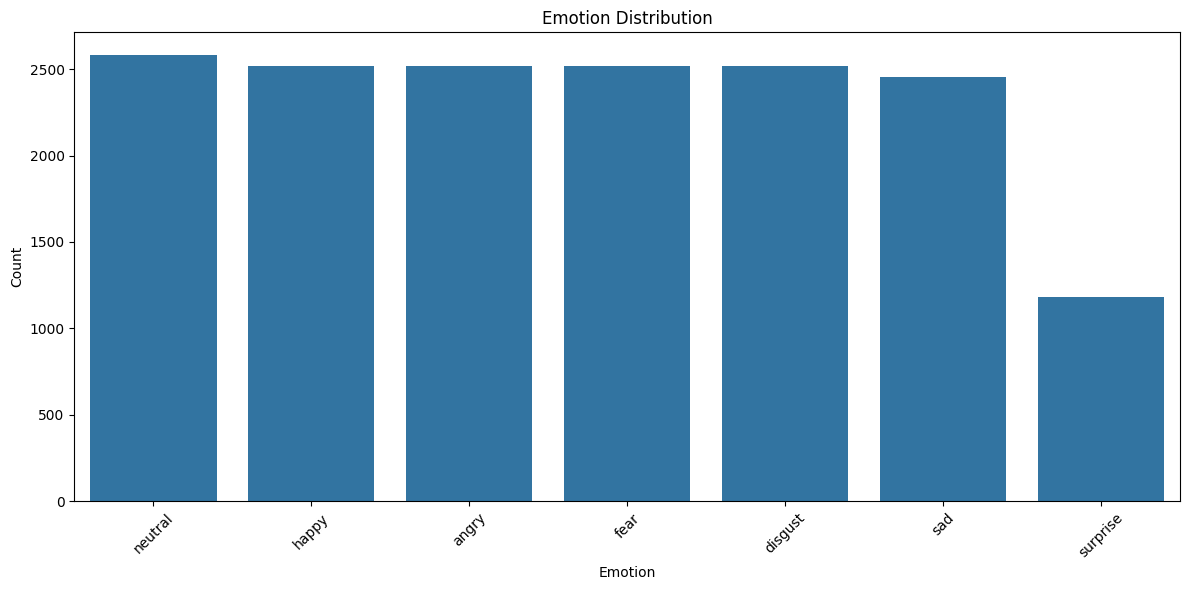

In [9]:
# Consolidate labels
label_mapping = {
    'surprised': 'surprise',
    'calm': 'neutral',
    'fearful': 'fear',
    'happiness': 'happy'
}

df['emotion'] = df['emotion'].replace(label_mapping)

print("\nEmotion distribution after consolidation:")
print(df['emotion'].value_counts())

# Visualize distribution
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='emotion', order=df['emotion'].value_counts().index)
plt.title('Emotion Distribution')
plt.xlabel('Emotion')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Extract Features

In [10]:
# Extract features for all audio files
print("Extracting features... This may take a while.")

features_list = []
labels_list = []

for idx, row in df.iterrows():
    if idx % 100 == 0:
        print(f"Processing {idx}/{len(df)}...")
    
    features = extract_features(row['path'])
    
    if features is not None:
        features_list.append(features)
        labels_list.append(row['emotion'])

print(f"\nFeature extraction complete! Total samples: {len(features_list)}")

# Convert to numpy arrays
X = np.array(features_list)
y = np.array(labels_list)

print(f"Feature shape: {X.shape}")
print(f"Labels shape: {y.shape}")

Extracting features... This may take a while.
Processing 0/16282...
Processing 100/16282...
Processing 200/16282...
Processing 300/16282...
Processing 400/16282...
Processing 500/16282...
Processing 600/16282...
Processing 700/16282...
Processing 800/16282...
Processing 900/16282...
Processing 1000/16282...
Processing 1100/16282...
Processing 1200/16282...
Processing 1300/16282...
Processing 1400/16282...
Processing 1500/16282...
Processing 1600/16282...
Processing 1700/16282...
Processing 1800/16282...
Processing 1900/16282...
Processing 2000/16282...
Processing 2100/16282...
Processing 2200/16282...
Processing 2300/16282...
Processing 2400/16282...
Processing 2500/16282...
Processing 2600/16282...
Processing 2700/16282...
Processing 2800/16282...
Processing 2900/16282...
Processing 3000/16282...
Processing 3100/16282...
Processing 3200/16282...
Processing 3300/16282...
Processing 3400/16282...
Processing 3500/16282...
Processing 3600/16282...
Processing 3700/16282...
Processing 3800/

## 4. Prepare Data for Training

In [11]:
# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
y_categorical = to_categorical(y_encoded)

# Get number of classes
num_classes = len(label_encoder.classes_)
print(f"Number of classes: {num_classes}")
print(f"Classes: {label_encoder.classes_}")

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y_categorical, test_size=0.2, random_state=42, stratify=y_encoded
)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape for Conv1D (samples, features, 1)
X_train = np.expand_dims(X_train, axis=2)
X_test = np.expand_dims(X_test, axis=2)

print(f"\nTraining set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test labels shape: {y_test.shape}")

Number of classes: 7
Classes: ['angry' 'disgust' 'fear' 'happy' 'neutral' 'sad' 'surprise']

Training set shape: (13025, 386, 1)
Test set shape: (3257, 386, 1)
Training labels shape: (13025, 7)
Test labels shape: (3257, 7)


## 5. Build Improved CNN-LSTM Model

In [12]:
def build_improved_model(input_shape, num_classes):
    """
    Build a CNN-LSTM hybrid model with:
    - Multiple convolutional layers for feature extraction
    - Bidirectional LSTM for temporal patterns
    - Batch normalization for stable training
    - Dropout for regularization
    """
    model = Sequential([
        # First Conv Block
        Conv1D(256, kernel_size=5, padding='same', activation='relu', input_shape=input_shape),
        BatchNormalization(),
        Conv1D(256, kernel_size=5, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        
        # Second Conv Block
        Conv1D(128, kernel_size=3, padding='same', activation='relu'),
        BatchNormalization(),
        Conv1D(128, kernel_size=3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        
        # Third Conv Block
        Conv1D(64, kernel_size=3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(0.3),
        
        # Bidirectional LSTM layers
        Bidirectional(LSTM(128, return_sequences=True)),
        Dropout(0.4),
        Bidirectional(LSTM(64)),
        Dropout(0.4),
        
        # Dense layers
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        
        # Output layer
        Dense(num_classes, activation='softmax')
    ])
    
    # Compile with Adam optimizer and lower learning rate
    optimizer = Adam(learning_rate=0.0001)
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# Build model
input_shape = (X_train.shape[1], X_train.shape[2])
model = build_improved_model(input_shape, num_classes)

# Display model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 386, 256)       │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 386, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 386, 256)       │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 386, 256)       │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 193, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 193, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 193, 128)       │        98,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 193, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 193, 128)       │        49,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 193, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 96, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 96, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 96, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 96, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 48, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 48, 256)        │       197,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 48, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 128)            │       164,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 893,127 (3.41 MB)

 Trainable params: 891,079 (3.40 MB)

 Non-trainable params: 2,048 (8.00 KB)

## 6. Train the Model

In [13]:
# Define callbacks
callbacks = [
    # Reduce learning rate when validation loss plateaus
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=0.00001,
        verbose=1
    ),
    
    # Stop training when validation loss stops improving
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    
    # Save best model
    ModelCheckpoint(
        'best_emotion_model.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )
]

# Train the model
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 609ms/step - accuracy: 0.1605 - loss: 2.9921
Epoch 1: val_accuracy improved from None to 0.14894, saving model to best_emotion_model.h5



Epoch 1: finished saving model to best_emotion_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 117s 653ms/step - accuracy: 0.1769 - loss: 2.8579 - val_accuracy: 0.1489 - val_loss: 2.1707 - learning_rate: 1.0000e-04
Epoch 2/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 568ms/step - accuracy: 0.2122 - loss: 2.5694
Epoch 2: val_accuracy improved from 0.14894 to 0.17620, saving model to best_emotion_model.h5



Epoch 2: finished saving model to best_emotion_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 97s 598ms/step - accuracy: 0.2206 - loss: 2.5292 - val_accuracy: 0.1762 - val_loss: 2.1889 - learning_rate: 1.0000e-04
Epoch 3/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 549ms/step - accuracy: 0.2286 - loss: 2.3998
Epoch 3: val_accuracy improved from 0.17620 to 0.23724, saving model to best_emotion_model.h5



Epoch 3: finished saving model to best_emotion_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 94s 577ms/step - accuracy: 0.2321 - loss: 2.3590 - val_accuracy: 0.2372 - val_loss: 2.0134 - learning_rate: 1.0000e-04
Epoch 4/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 559ms/step - accuracy: 0.2580 - loss: 2.2262
Epoch 4: val_accuracy improved from 0.23724 to 0.29136, saving model to best_emotion_model.h5



Epoch 4: finished saving model to best_emotion_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 96s 587ms/step - accuracy: 0.2566 - loss: 2.2102 - val_accuracy: 0.2914 - val_loss: 1.7635 - learning_rate: 1.0000e-04
Epoch 5/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 589ms/step - accuracy: 0.2737 - loss: 2.1195
Epoch 5: val_accuracy improved from 0.29136 to 0.34626, saving model to best_emotion_model.h5


...


Epoch 71: finished saving model to best_emotion_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 92s 562ms/step - accuracy: 0.6882 - loss: 0.8391 - val_accuracy: 0.6733 - val_loss: 0.8352 - learning_rate: 1.0000e-04
Epoch 72/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.6844 - loss: 0.8516
Epoch 72: val_accuracy did not improve from 0.67332
163/163 ━━━━━━━━━━━━━━━━━━━━ 90s 554ms/step - accuracy: 0.6857 - loss: 0.8422 - val_accuracy: 0.6679 - val_loss: 0.8390 - learning_rate: 1.0000e-04
Epoch 73/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 565ms/step - accuracy: 0.6822 - loss: 0.8422
Epoch 73: val_accuracy did not improve from 0.67332
163/163 ━━━━━━━━━━━━━━━━━━━━ 97s 593ms/step - accuracy: 0.6839 - loss: 0.8347 - val_accuracy: 0.6722 - val_loss: 0.8270 - learning_rate: 1.0000e-04
Epoch 74/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.6897 - loss: 0.8492
Epoch 74: val_accuracy did not improve from 0.67332
163/163 ━━━━━━━━━━━━━━━━━━━━ 95s 583ms/step - accuracy: 0.6868 - loss: 0


Epoch 75: finished saving model to best_emotion_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 107s 658ms/step - accuracy: 0.6916 - loss: 0.8217 - val_accuracy: 0.6756 - val_loss: 0.8250 - learning_rate: 1.0000e-04
Epoch 76/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 605ms/step - accuracy: 0.6875 - loss: 0.8336
Epoch 76: val_accuracy did not improve from 0.67562
163/163 ━━━━━━━━━━━━━━━━━━━━ 103s 633ms/step - accuracy: 0.6940 - loss: 0.8224 - val_accuracy: 0.6599 - val_loss: 0.8593 - learning_rate: 1.0000e-04
Epoch 77/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 563ms/step - accuracy: 0.6924 - loss: 0.8223
Epoch 77: val_accuracy did not improve from 0.67562
163/163 ━━━━━━━━━━━━━━━━━━━━ 97s 592ms/step - accuracy: 0.6958 - loss: 0.8129 - val_accuracy: 0.6603 - val_loss: 0.8741 - learning_rate: 1.0000e-04
Epoch 78/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.6929 - loss: 0.8209
Epoch 78: val_accuracy improved from 0.67562 to 0.68023, saving model to best_emotion_model.h5



Epoch 78: finished saving model to best_emotion_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 96s 586ms/step - accuracy: 0.7002 - loss: 0.8118 - val_accuracy: 0.6802 - val_loss: 0.8162 - learning_rate: 1.0000e-04
Epoch 79/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.6932 - loss: 0.8262
Epoch 79: val_accuracy improved from 0.68023 to 0.68215, saving model to best_emotion_model.h5



Epoch 79: finished saving model to best_emotion_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 96s 586ms/step - accuracy: 0.6944 - loss: 0.8186 - val_accuracy: 0.6821 - val_loss: 0.8174 - learning_rate: 1.0000e-04
Epoch 80/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 563ms/step - accuracy: 0.6937 - loss: 0.8220
Epoch 80: val_accuracy did not improve from 0.68215
163/163 ━━━━━━━━━━━━━━━━━━━━ 97s 592ms/step - accuracy: 0.7036 - loss: 0.8020 - val_accuracy: 0.6806 - val_loss: 0.8225 - learning_rate: 1.0000e-04
Epoch 81/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 555ms/step - accuracy: 0.6979 - loss: 0.7980
Epoch 81: val_accuracy did not improve from 0.68215
163/163 ━━━━━━━━━━━━━━━━━━━━ 95s 583ms/step - accuracy: 0.7019 - loss: 0.7932 - val_accuracy: 0.6768 - val_loss: 0.8201 - learning_rate: 1.0000e-04
Epoch 82/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 560ms/step - accuracy: 0.7002 - loss: 0.7993
Epoch 82: val_accuracy did not improve from 0.68215
163/163 ━━━━━━━━━━━━━━━━━━━━ 96s 589ms/step - accuracy: 0.7042 - loss: 0


Epoch 92: finished saving model to best_emotion_model.h5
163/163 ━━━━━━━━━━━━━━━━━━━━ 104s 635ms/step - accuracy: 0.7323 - loss: 0.7233 - val_accuracy: 0.6944 - val_loss: 0.8096 - learning_rate: 5.0000e-05
Epoch 93/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 587ms/step - accuracy: 0.7390 - loss: 0.7227
Epoch 93: val_accuracy did not improve from 0.69443
163/163 ━━━━━━━━━━━━━━━━━━━━ 101s 617ms/step - accuracy: 0.7371 - loss: 0.7192 - val_accuracy: 0.6637 - val_loss: 0.8762 - learning_rate: 5.0000e-05
Epoch 94/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 570ms/step - accuracy: 0.7316 - loss: 0.7390
Epoch 94: val_accuracy did not improve from 0.69443
163/163 ━━━━━━━━━━━━━━━━━━━━ 98s 598ms/step - accuracy: 0.7395 - loss: 0.7177 - val_accuracy: 0.6749 - val_loss: 0.8422 - learning_rate: 5.0000e-05
Epoch 95/100
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 564ms/step - accuracy: 0.7364 - loss: 0.7210
Epoch 95: val_accuracy did not improve from 0.69443
163/163 ━━━━━━━━━━━━━━━━━━━━ 97s 592ms/step - accuracy: 0.7369 - loss:

## 7. Evaluate the Model

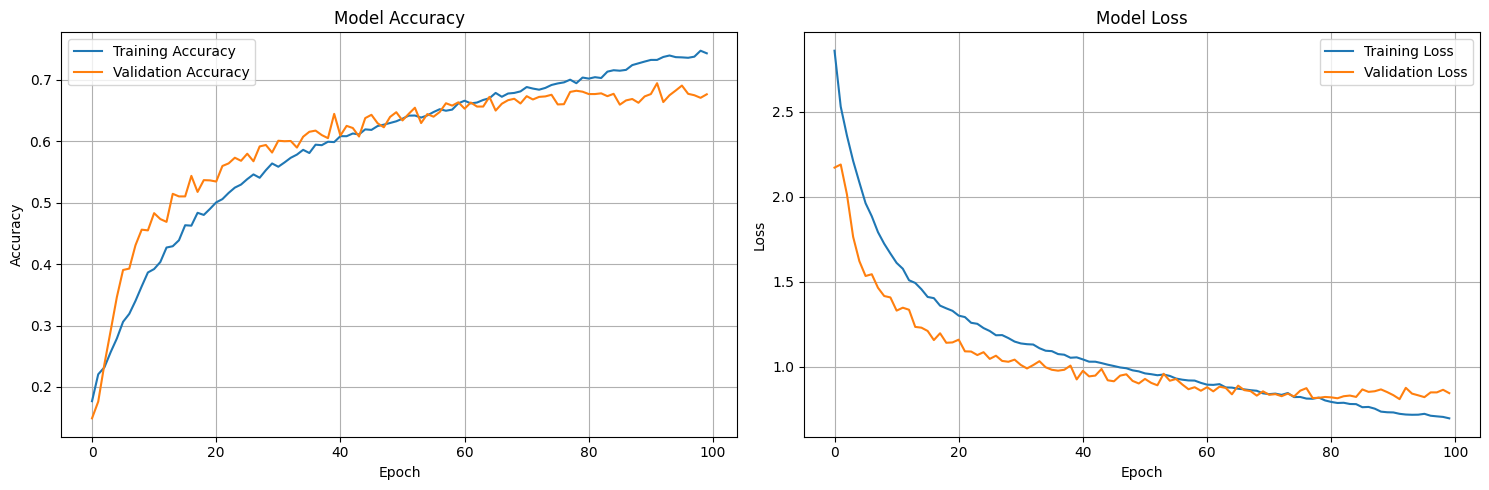

In [14]:
# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Accuracy plot
axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [15]:
# Evaluate on test set
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy*100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

# Make predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_test_classes = np.argmax(y_test, axis=1)

# Classification report
print("\nClassification Report:")
print(classification_report(
    y_test_classes, 
    y_pred_classes,
    target_names=label_encoder.classes_
))


Test Accuracy: 68.35%
Test Loss: 0.8267
102/102 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step

Classification Report:
              precision    recall  f1-score   support

       angry       0.74      0.81      0.77       503
     disgust       0.51      0.70      0.59       503
        fear       0.91      0.50      0.65       503
       happy       0.67      0.54      0.60       503
     neutral       0.62      0.79      0.69       517
         sad       0.73      0.68      0.71       491
    surprise       0.91      0.85      0.88       237

    accuracy                           0.68      3257
   macro avg       0.73      0.70      0.70      3257
weighted avg       0.71      0.68      0.68      3257



In [16]:
import numpy as np

# 1. Get the index of the highest probability for each prediction
y_pred_indices = np.argmax(y_pred, axis=1)
# 2. Convert those indices back to original labels ('happy', 'sad', etc.)
y_pred = label_encoder.inverse_transform(y_pred_indices)

# 3. Do the same for your ground truth if it is still one-hot encoded
y_test_indices = np.argmax(y_test, axis=1)
y_test_labels = label_encoder.inverse_transform(y_test_indices)

In [17]:
df = pd.DataFrame(columns=['Predicted Labels', 'Actual Labels'])
df['Predicted Labels'] = y_pred.flatten()
df['Actual Labels'] = y_test_labels.flatten()

df.head(10)

,Predicted Labels,Actual Labels
0,angry,angry
1,angry,surprise
2,surprise,surprise
3,disgust,happy
4,fear,fear
5,surprise,happy
6,neutral,fear
7,angry,happy
8,disgust,disgust
9,disgust,sad


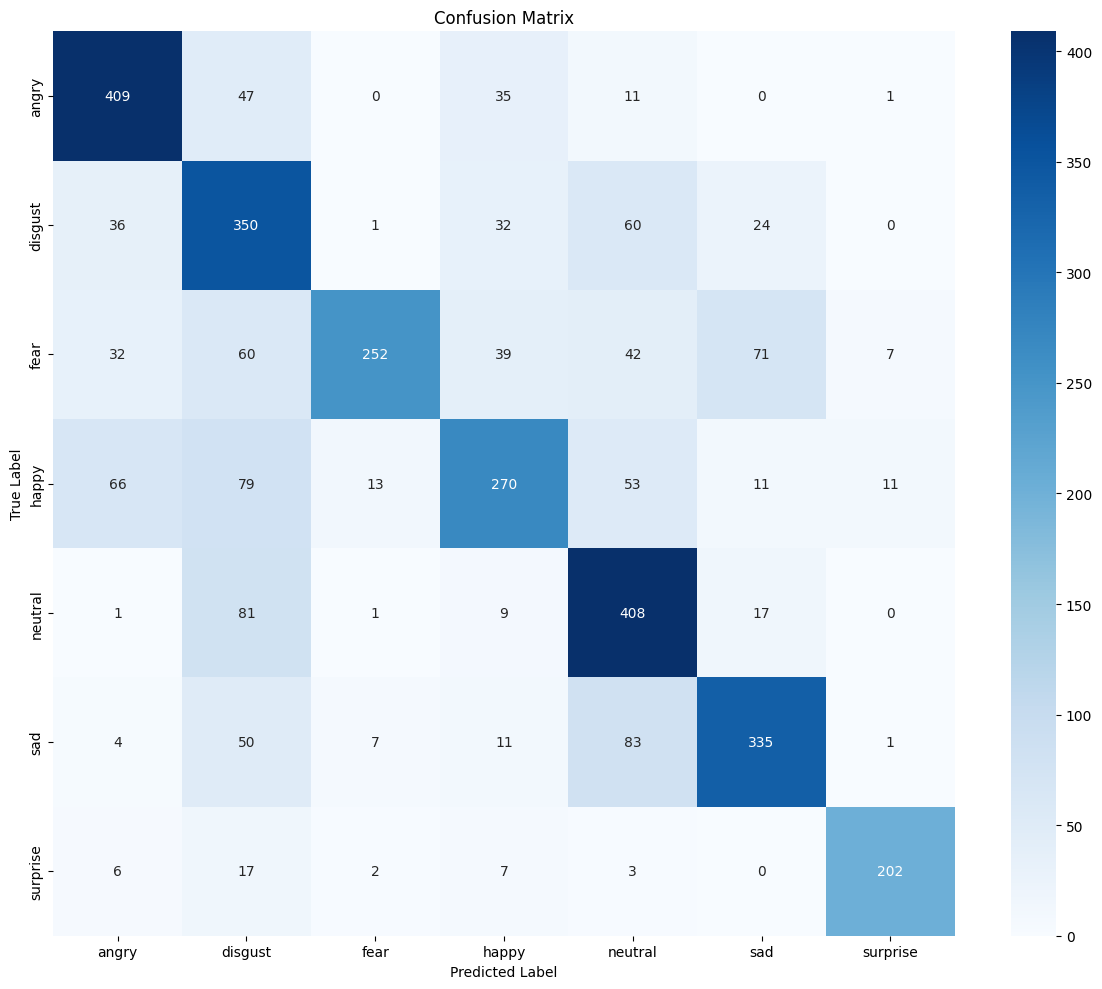

angry: 81.31%
disgust: 69.58%
fear: 50.10%
happy: 53.68%
neutral: 78.92%
sad: 68.23%
surprise: 85.23%


In [18]:
# Confusion Matrix
cm = confusion_matrix(y_test_classes, y_pred_classes)

plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# Per-class accuracy
class_accuracy = cm.diagonal() / cm.sum(axis=1)
for i, emotion in enumerate(label_encoder.classes_):
    print(f"{emotion}: {class_accuracy[i]*100:.2f}%")

## 8. Save the Model and Preprocessing Objects

In [19]:
# Save the model
model.save('emotion_recognition_model.h5')
print("Model saved as 'emotion_recognition_model.h5'")

# Save the label encoder and scaler
import pickle

with open('label_encoder.pkl', 'wb') as f:
    pickle.dump(label_encoder, f)

with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("Label encoder and scaler saved!")

Model saved as 'emotion_recognition_model.h5'
Label encoder and scaler saved!


## 9. Test on New Audio

In [20]:
def predict_emotion(audio_path, model, scaler, label_encoder):
    """
    Predict emotion from a new audio file
    """
    # Extract features
    features = extract_features(audio_path)
    
    if features is None:
        return None
    
    # Preprocess
    features = features.reshape(1, -1)
    features = scaler.transform(features)
    features = np.expand_dims(features, axis=2)
    
    # Predict
    prediction = model.predict(features)
    predicted_class = np.argmax(prediction)
    predicted_emotion = label_encoder.inverse_transform([predicted_class])[0]
    confidence = prediction[0][predicted_class]
    
    return predicted_emotion, confidence

# Example usage:
# audio_file = "path/to/your/audio.wav"
# emotion, confidence = predict_emotion(audio_file, model, scaler, label_encoder)
# print(f"Predicted emotion: {emotion} (confidence: {confidence*100:.2f}%)")